Số chiều sau PCA: 7
K-Means thực hiện với K=4 (Ép phân cụm để tìm segment)
DBSCAN hoàn tất: eps=2.79, Tìm thấy: 1 cụm

--- BẢNG SO SÁNH ĐỊNH LƯỢNG ---
           Model  Silhouette Score  Calinski-Harabasz        Clusters Found
0        K-Means            0.2139          1221.6902                     4
1         DBSCAN            0.0000             0.0000  N/A (Too much noise)
2  Agglomerative            0.1855          1052.5739                     4


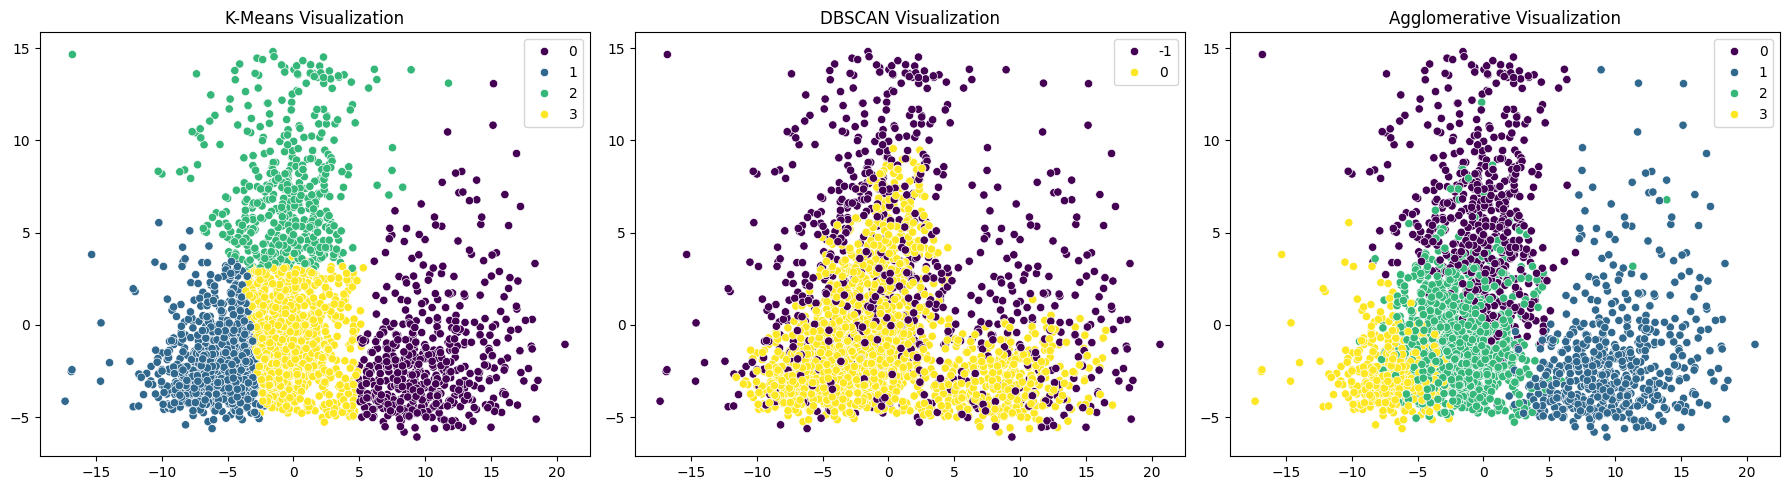

In [2]:
# 1. IMPORT THƯ VIỆN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors


from sklearn.decomposition import PCA
# 2. LOAD VÀ CHUẨN HÓA DỮ LIỆU
# Giả sử file đầu vào là kết quả từ bước trước của bạn
df_full = pd.read_csv(r"C:\Users\Admin\Desktop\TANPHAT\hocotruong\Năm ba 2025-2026\HK2_A\Phantichvatrucquandulieu\DA_cuoimon\data_creator_unique.csv")

df_full.drop(columns=['CREATOR_ID'], inplace=True)

# 2. PCA - Giảm chiều dữ liệu (QUAN TRỌNG cho DBSCAN và độ chính xác)
# Giữ lại 90% thông tin quan trọng nhất
pca_full = PCA(n_components=0.95, random_state=42) 
X_pca = pca_full.fit_transform(df_full)
print(f"Số chiều sau PCA: {X_pca.shape[1]}") # Thường sẽ còn 5-8 chiều

# ---------------------------------------------------------
# 3. TRIỂN KHAI 3 MODELS VÀ TÌM THAM SỐ TỐI ƯU
# ---------------------------------------------------------

# --- Model 1: K-Means (Tìm K tối ưu qua Silhouette Score) ---
best_k = 2
max_silhouette = -1
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_full)
    score = silhouette_score(df_full, labels)
    if score > max_silhouette:
        max_silhouette = score
        best_k = k

forced_k = 4 
model_kmeans = KMeans(n_clusters=forced_k, random_state=42, n_init=10)
labels_kmeans = model_kmeans.fit_predict(X_pca) # Chạy trên PCA để chính xác hơn
print(f"K-Means thực hiện với K={forced_k} (Ép phân cụm để tìm segment)")

# --- Model 2: DBSCAN (Tìm eps tối ưu bằng K-Dist Plot) ---
# Sử dụng phương pháp Elbow trên đồ thị khoảng cách lân cận
neigh = NearestNeighbors(n_neighbors=X_pca.shape[1] * 2)
nbrs = neigh.fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)
suggested_eps = np.percentile(distances[:, -1], 85) # Lấy phân vị 85

# (Trong thực tế bạn cần nhìn đồ thị này để chọn điểm gãy - elbow)
# Ở đây tôi chọn một giá trị eps mặc định phổ biến hoặc tự động ước lượng
optimal_eps = distances[int(len(distances)*0.9)] # Ước lượng tại phân vị 90

fine_tuned_eps = suggested_eps * 0.7 
model_dbscan = DBSCAN(eps=fine_tuned_eps, min_samples=15) # Tăng min_samples để tránh cụm quá nhỏ
labels_dbscan = model_dbscan.fit_predict(X_pca)


n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
print(f"DBSCAN hoàn tất: eps={fine_tuned_eps:.2f}, Tìm thấy: {n_clusters_db} cụm")

# --- Model 3: Agglomerative (Sử dụng số cụm của K-Means) ---
model_agg = AgglomerativeClustering(n_clusters=forced_k)
labels_agg = model_agg.fit_predict(X_pca)
# ---------------------------------------------------------
# 4. SO SÁNH CÁC MÔ HÌNH BẰNG CHỈ SỐ ĐÁNG TIN CẬY
# ---------------------------------------------------------

def evaluate_model(name, labels, data):
    # Loại bỏ nhiễu (-1) của DBSCAN khi tính chỉ số để công bằng
    mask = labels != -1
    if sum(mask) < 2 or len(set(labels[mask])) < 2:
        return [name, 0, 0, "N/A (Too much noise)"]
    
    sil = silhouette_score(data[mask], labels[mask])
    ch = calinski_harabasz_score(data[mask], labels[mask])
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return [name, sil, ch, n_clusters]

results = [
    evaluate_model("K-Means", labels_kmeans, df_full),
    evaluate_model("DBSCAN", labels_dbscan, df_full),
    evaluate_model("Agglomerative", labels_agg, df_full)
]

comparison_df = pd.DataFrame(results, columns=['Model', 'Silhouette Score', 'Calinski-Harabasz', 'Clusters Found'])

print("\n--- BẢNG SO SÁNH ĐỊNH LƯỢNG ---")
print(comparison_df.round(4))

# 5. TRỰC QUAN HÓA KẾT QUẢ (Sử dụng 2 thành phần chính PCA)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_full)

plt.figure(figsize=(18, 5))

titles = ['K-Means', 'DBSCAN', 'Agglomerative']
all_labels = [labels_kmeans, labels_dbscan, labels_agg]

for i in range(3):
    plt.subplot(1, 3, i+1)
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=all_labels[i], palette='viridis', legend='full')
    plt.title(f'{titles[i]} Visualization')

plt.tight_layout()
plt.show()


In [5]:
df_full.columns

Index(['CREATOR_ID', 'log1p_followers', 'log1p_median_views',
       'log1p_price_num', 'engagement_rate_profile', 'price_per_view',
       'total_video_90d', 'dominant_session', 'active_days_count',
       'log1p_view_count', 'log1p_like_count', 'avg_view_count',
       'var_view_count', 'median_view_video', 'max_view', 'p90_view',
       'p60_view', 'p30_view', 'avg_like', 'avg_comment', 'avg_share',
       'avg_save', 'avg_like_rate', 'avg_comment_rate', 'avg_share_rate',
       'avg_save_rate', 'avg_engagement_rate', 'view_ratio', 'videos_per_week',
       'cv_view', 'std_like_rate', 'virality_score', 'consistency_score',
       'burstiness', 'Cluster'],
      dtype='object')

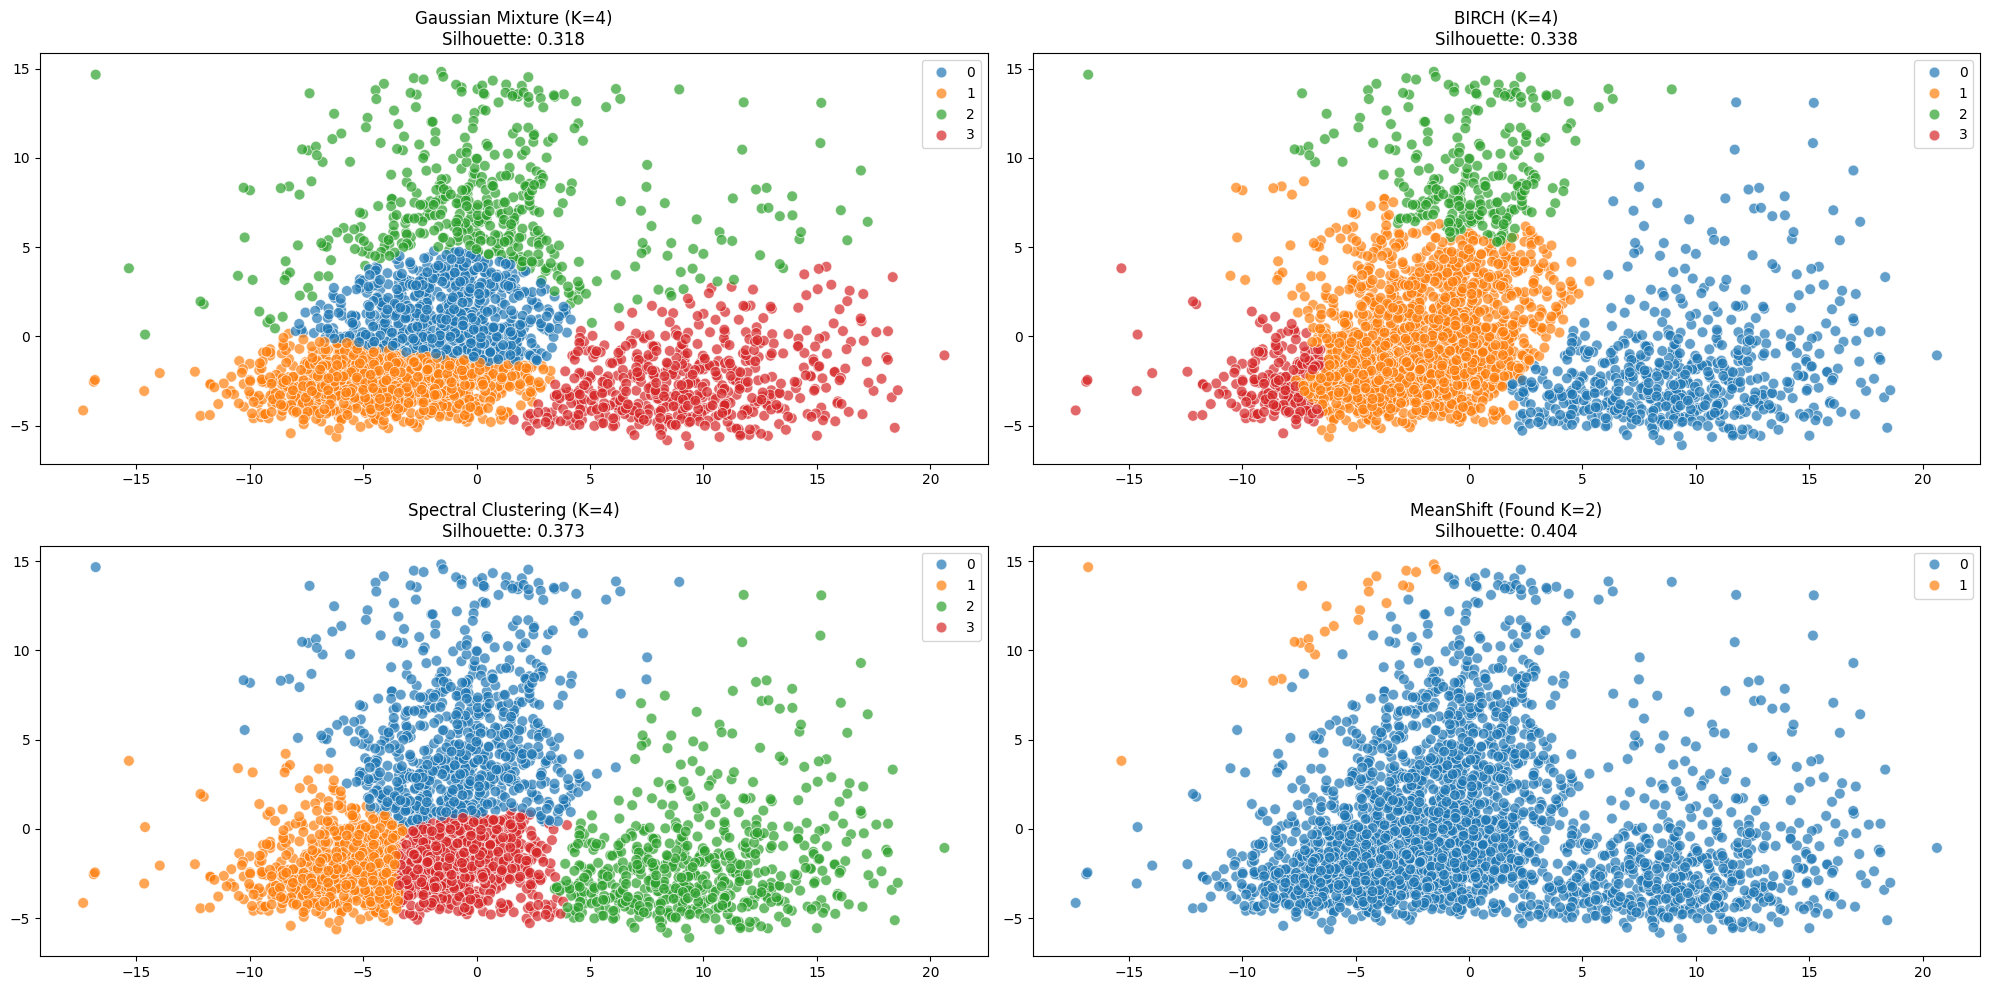

In [3]:

from sklearn.mixture import GaussianMixture
from sklearn.cluster import Birch, SpectralClustering, MeanShift
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập số cụm K=4 (dựa trên kết quả tối ưu từ K-Means của bạn)
n_clusters = 4

# --- Triển khai 4 Model ---

# 1. GMM (Xác suất hình Elip)
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
labels_gmm = gmm.fit_predict(X_pca)

# 2. BIRCH (Phân cấp cho dữ liệu lớn)
birch = Birch(n_clusters=n_clusters)
labels_birch = birch.fit_predict(X_pca)

# 3. Spectral Clustering (Tìm cấu trúc đồ thị)
# Dùng n_neighbors để mô hình nhạy hơn với dữ liệu TikTok
spectral = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=42)
labels_spectral = spectral.fit_predict(X_pca)

# 4. MeanShift (Tự động tìm số cụm dựa trên mật độ)
meanshift = MeanShift(bandwidth=None) # bandwidth=None để tự động ước lượng
labels_ms = meanshift.fit_predict(X_pca)
n_ms = len(np.unique(labels_ms))

# --- Vẽ biểu đồ so sánh 4 Model ---

plt.figure(figsize=(20, 10))
titles = [
    f'Gaussian Mixture (K={n_clusters})', 
    f'BIRCH (K={n_clusters})', 
    f'Spectral Clustering (K={n_clusters})', 
    f'MeanShift (Found K={n_ms})'
]
all_labels = [labels_gmm, labels_birch, labels_spectral, labels_ms]

for i in range(4):
    plt.subplot(2, 2, i+1)
    # Sử dụng 2 thành phần PCA đầu tiên để vẽ
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=all_labels[i], palette='tab10', s=60, alpha=0.7)
    
    # Tính Silhouette Score để ghi chú lên hình
    if len(np.unique(all_labels[i])) > 1:
        score = silhouette_score(X_pca, all_labels[i])
        plt.title(f"{titles[i]}\nSilhouette: {score:.3f}")
    else:
        plt.title(f"{titles[i]}\nSilhouette: N/A (1 cluster)")
    
plt.tight_layout()
plt.show()